# Kapitel 3: Wörter werden zu Zahlen

## Bisher...

Wir haben aus 3,6 Millionen echten Amazon-Bewertungen eine Stichprobe von ~400.000 gezogen (Kap. 1),
die natürliche Verteilung analysiert, das Klassenungleichgewicht durch Undersampling korrigiert
und die Texte normalisiert (Kap. 2).

## Das Problem

Eine Maschine kann nicht lesen. Sie versteht weder *"great"* noch *"terrible"*.
Wir müssen jeden Text in einen **numerischen Vektor** verwandeln —
so, dass die Bedeutung erhalten bleibt.

## Die Lösung: TF-IDF

**TF-IDF** (Term Frequency – Inverse Document Frequency) misst die Relevanz eines Wortes:
- **TF** — Wie oft kommt das Wort in *diesem* Review vor?
- **IDF** — Wie selten ist es im *gesamten* Datensatz?
- **TF × IDF** — Einzigartig-wichtige Wörter erhalten hohe Werte

## 3.1 Bereinigte Daten laden

In [8]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AmazonReviews – Tokenisierung & TF-IDF") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

df = spark.read.parquet(
    "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/cleaned_reviews.parquet"
)

print(f"Daten geladen: {df.count():,} Zeilen")
df.printSchema()
df.show(3, truncate=80)

26/03/30 13:37:11 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


Daten geladen: 399,553 Zeilen
root
 |-- label: integer (nullable = true)
 |-- summary: string (nullable = true)
 |-- text: string (nullable = true)

+-----+-------------+--------------------------------------------------------------------------------+
|label|      summary|                                                                            text|
+-----+-------------+--------------------------------------------------------------------------------+
|    0|disappointing|hoover s choice of international financial manipulation as subject matter for...|
|    0|       beware|yeah it s kind of over the top funny especially in the way it portrays the ch...|
|    0|holy dear god|where to start how about this just as annoying as the super agent who knows e...|
+-----+-------------+--------------------------------------------------------------------------------+
only showing top 3 rows


## 3.2 Schritt 1: Tokenisierung

*"this book is great"* → `["this", "book", "is", "great"]`

In [9]:
from pyspark.ml.feature import Tokenizer

tokenizer = Tokenizer(inputCol="text", outputCol="tokens")
df_tokens = tokenizer.transform(df)
df_tokens.select("text", "tokens").show(3, truncate=80)

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                            text|                                                                          tokens|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|hoover s choice of international financial manipulation as subject matter for...|[hoover, s, choice, of, international, financial, manipulation, as, subject, ...|
|yeah it s kind of over the top funny especially in the way it portrays the ch...|[yeah, it, s, kind, of, over, the, top, funny, especially, in, the, way, it, ...|
|where to start how about this just as annoying as the super agent who knows e...|[where, to, start, how, about, this, just, as, annoying, as, the, super, agen...|
+---------------

In [10]:
from pyspark.sql.functions import size, avg, min as spark_min, max as spark_max, round as spark_round, col

df_tokens.withColumn("token_count", size("tokens")).select(
    spark_min("token_count").alias("Min"),
    spark_round(avg("token_count"), 0).alias("Durchschnitt"),
    spark_max("token_count").alias("Max")
).show()

+---+------------+---+
|Min|Durchschnitt|Max|
+---+------------+---+
|  1|        76.0|215|
+---+------------+---+



## 3.3 Schritt 2: StopWords entfernen

`["this", "book", "is", "great"]` → `["book", "great"]`

In [11]:
from pyspark.ml.feature import StopWordsRemover

remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
df_filtered = remover.transform(df_tokens)
df_filtered.select("tokens", "filtered_tokens").show(3, truncate=80)

26/03/30 13:37:19 WARN StopWordsRemover: Default locale set was [tr_DE]; however, it was not found in available locales in JVM, falling back to en_US locale. Set param `locale` in order to respect another locale.


+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                          tokens|                                                                 filtered_tokens|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[hoover, s, choice, of, international, financial, manipulation, as, subject, ...|[hoover, choice, international, financial, manipulation, subject, matter, nov...|
|[yeah, it, s, kind, of, over, the, top, funny, especially, in, the, way, it, ...|[yeah, kind, top, funny, especially, way, portrays, character, rabid, moz, fa...|
|[where, to, start, how, about, this, just, as, annoying, as, the, super, agen...|[start, annoying, super, agent, knows, everything, always, right, tools, get,...|
+---------------

In [12]:
df_compare = df_filtered \
    .withColumn("before", size("tokens")) \
    .withColumn("after", size("filtered_tokens")) \
    .withColumn("removed", col("before") - col("after"))

df_compare.select(
    spark_round(avg("before"), 1).alias("Tokens vorher"),
    spark_round(avg("after"), 1).alias("Tokens nachher"),
    spark_round(avg("removed"), 1).alias("Entfernt (Durchschnitt)")
).show()

+-------------+--------------+-----------------------+
|Tokens vorher|Tokens nachher|Entfernt (Durchschnitt)|
+-------------+--------------+-----------------------+
|         75.8|          37.2|                   38.7|
+-------------+--------------+-----------------------+



## 3.4 Welche Wörter verraten die Stimmung?

In [13]:
from pyspark.sql.functions import explode, count as spark_count

df_words = df_filtered.select("label", explode("filtered_tokens").alias("word"))

print("=== Top 15 Wörter – POSITIV ===")
df_words.filter(col("label") == 1) \
    .groupBy("word").agg(spark_count("*").alias("count")) \
    .orderBy(col("count").desc()).show(15)

print("=== Top 15 Wörter – NEGATIV ===")
df_words.filter(col("label") == 0) \
    .groupBy("word").agg(spark_count("*").alias("count")) \
    .orderBy(col("count").desc()).show(15)

=== Top 15 Wörter – POSITIV ===


+------+------+
|  word| count|
+------+------+
|  book|101885|
|   one| 70228|
| great| 66014|
|  like| 52127|
|  good| 51806|
|  read| 40355|
|  well| 36278|
|  love| 34296|
|  time| 33207|
|really| 31482|
|   get| 31329|
| movie| 26679|
|  best| 26485|
| first| 26036|
|    cd| 25691|
+------+------+
only showing top 15 rows
=== Top 15 Wörter – NEGATIV ===


+-------+-----+
|   word|count|
+-------+-----+
|   book|98325|
|    one|74389|
|   like|57978|
|    get|41901|
|   good|41394|
|   time|37297|
|   even|34553|
|  movie|32875|
|   read|30709|
| really|29471|
|   much|29042|
|product|28209|
|  first|27590|
|    buy|27269|
|  money|25357|
+-------+-----+
only showing top 15 rows


## 3.5 Schritt 3: TF-IDF berechnen

In [14]:
from pyspark.ml.feature import HashingTF, IDF

hashing_tf = HashingTF(inputCol="filtered_tokens", outputCol="raw_features", numFeatures=10000)
df_tf = hashing_tf.transform(df_filtered)
print("HashingTF abgeschlossen.")
df_tf.select("filtered_tokens", "raw_features").show(2, truncate=80)

HashingTF abgeschlossen.
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                 filtered_tokens|                                                                    raw_features|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|[hoover, choice, international, financial, manipulation, subject, matter, nov...|(10000,[188,596,1073,1106,1286,1439,1676,1948,2312,2402,3383,3826,3857,4165,4...|
|[yeah, kind, top, funny, especially, way, portrays, character, rabid, moz, fa...|(10000,[78,80,211,232,635,734,820,947,1182,1439,1963,2137,2543,3037,3231,3249...|
+--------------------------------------------------------------------------------+-------------------------------------------------------------------------

In [15]:
idf = IDF(inputCol="raw_features", outputCol="tfidf_features")
idf_model = idf.fit(df_tf)
df_tfidf = idf_model.transform(df_tf)
print("IDF-Berechnung abgeschlossen.")
df_tfidf.select("label", "filtered_tokens", "tfidf_features").show(2, truncate=80)

IDF-Berechnung abgeschlossen.
+-----+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|label|                                                                 filtered_tokens|                                                                  tfidf_features|
+-----+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|    0|[hoover, choice, international, financial, manipulation, subject, matter, nov...|(10000,[188,596,1073,1106,1286,1439,1676,1948,2312,2402,3383,3826,3857,4165,4...|
|    0|[yeah, kind, top, funny, especially, way, portrays, character, rabid, moz, fa...|(10000,[78,80,211,232,635,734,820,947,1182,1439,1963,2137,2543,3037,3231,3249...|
+-----+--------------------------------------------------------------------------------+--------------------------------

## 3.6 Feature-Vektor inspizieren

In [16]:
sample = df_tfidf.select("tfidf_features").first()[0]

print(f"Vektor-Typ:   {type(sample).__name__}")
print(f"Dimensionen:  {sample.size}")
print(f"Nicht-Null:   {len(sample.indices)} Einträge")

Vektor-Typ:   SparseVector
Dimensionen:  10000
Nicht-Null:   44 Einträge


## 3.7 Ergebnisse speichern

In [17]:
df_output = df_tfidf.select("label", "text", "filtered_tokens", "tfidf_features")

output_path = "/Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/tfidf_features.parquet"
df_output.write.parquet(output_path, mode="overwrite")
print(f"Gespeichert: {output_path}")

df_check = spark.read.parquet(output_path)
print(f"Parquet gelesen: {df_check.count():,} Zeilen")

Gespeichert: /Users/alperbildiren/PYSPARK_AMAZON_PROJECT/output/tfidf_features.parquet
Parquet gelesen: 399,553 Zeilen


## 3.8 Visualisierung

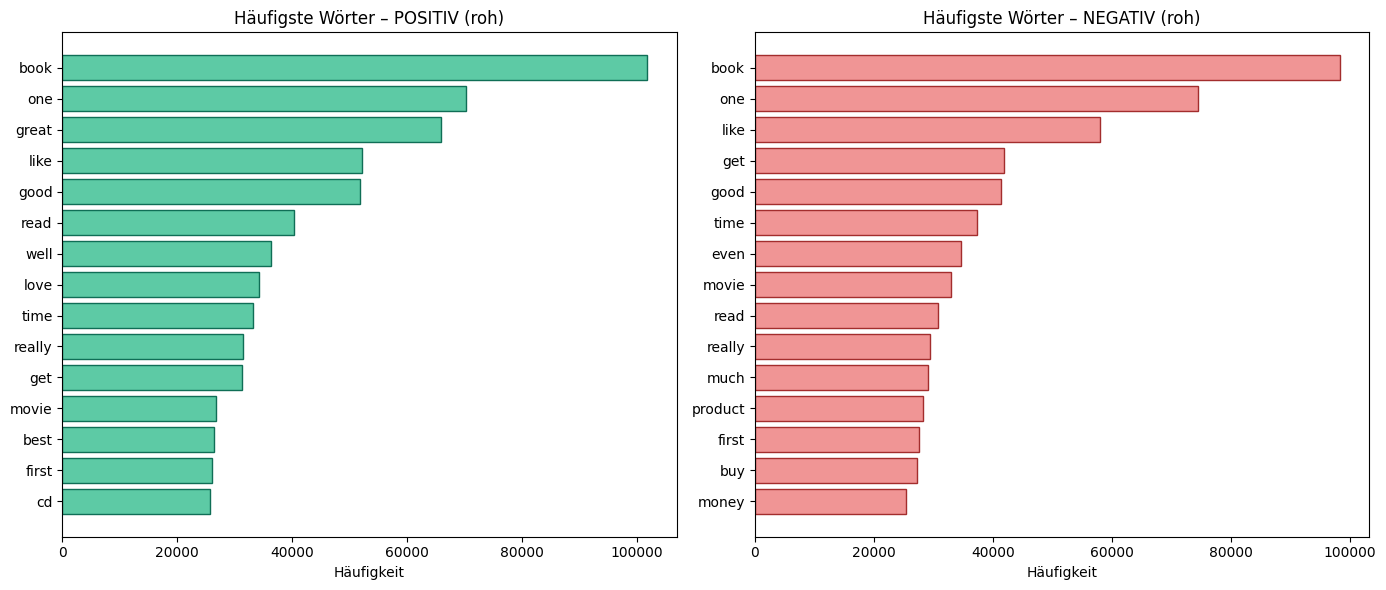

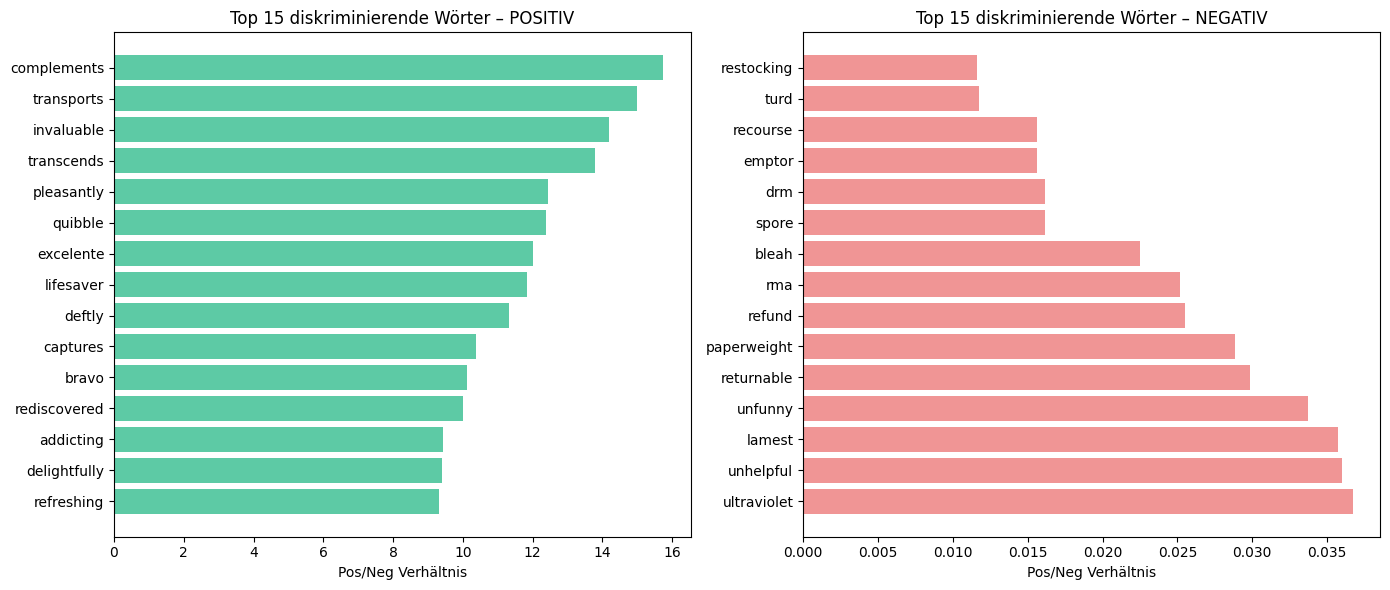

In [24]:
import matplotlib.pyplot as plt

top_pos = df_words.filter(col("label") == 1) \
    .groupBy("word").agg(spark_count("*").alias("count")) \
    .orderBy(col("count").desc()).limit(15).toPandas()

top_neg = df_words.filter(col("label") == 0) \
    .groupBy("word").agg(spark_count("*").alias("count")) \
    .orderBy(col("count").desc()).limit(15).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pos["word"][::-1], top_pos["count"][::-1], color="#5DCAA5", edgecolor="#0F6E56")
axes[0].set_title("Häufigste Wörter – POSITIV (roh)")
axes[0].set_xlabel("Häufigkeit")

axes[1].barh(top_neg["word"][::-1], top_neg["count"][::-1], color="#F09595", edgecolor="#A32D2D")
axes[1].set_title("Häufigste Wörter – NEGATIV (roh)")
axes[1].set_xlabel("Häufigkeit")

plt.tight_layout()
plt.show()


# Diskriminierende Wörter

pos_counts = df_words.filter(col("label") == 1) \
    .groupBy("word").agg(spark_count("*").alias("pos"))

neg_counts = df_words.filter(col("label") == 0) \
    .groupBy("word").agg(spark_count("*").alias("neg"))

df_join = pos_counts.join(neg_counts, "word")

df_join = df_join.filter(
    (col("pos") + col("neg")) > 50
)

df_ratio = df_join.withColumn(
    "ratio",
    col("pos") / (col("neg") + 1)
)

top_pos_ratio = df_ratio.orderBy(col("ratio").desc()).limit(15).toPandas()
top_neg_ratio = df_ratio.orderBy(col("ratio").asc()).limit(15).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pos_ratio["word"][::-1], top_pos_ratio["ratio"][::-1], color="#5DCAA5")
axes[0].set_title("Top 15 diskriminierende Wörter – POSITIV")
axes[0].set_xlabel("Pos/Neg Verhältnis")

axes[1].barh(top_neg_ratio["word"][::-1], top_neg_ratio["ratio"][::-1], color="#F09595")
axes[1].set_title("Top 15 diskriminierende Wörter – NEGATIV")
axes[1].set_xlabel("Pos/Neg Verhältnis")

plt.tight_layout()
plt.show()

## Kapitel 3 — Zusammenfassung

| Schritt | Werkzeug | Was passiert? |
|---------|----------|---------------|
| Tokenisierung | `Tokenizer` | Text → Wortliste |
| StopWords | `StopWordsRemover` | Bedeutungslose Wörter entfernen |
| TF | `HashingTF(10000)` | Wörter → Häufigkeits-Vektoren |
| IDF | `IDF` | Häufigkeiten → Relevanz-Gewichtung |

**Nächstes Kapitel:** Die Maschine lernt — Logistic Regression auf echten Trainingsdaten.